Code for calculating the barotropic and overturning streamfunctions for both ANHA4 and ANHA12. This assumes that for the barotropic streamfunction, you start from the north and work your way down

In [2]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

import datetime
import cftime
import time

import gsw

In [2]:
def get_files(path, mask_path):
    files = []
    for x in ['_gridU.nc','_gridV.nc','_gridT.nc']:
       files.append(xr.open_mfdataset(path + x))
    mask = xr.open_mfdataset(mask_path)
    return files, mask

In [3]:
def barotropic_sf(file, mask, inds):
    ds_u = files[0].rename({'depthu': 'depth'})
    ds_v = files[1].rename({'depthv': 'depth'})
    
    i_face = (ds_u['e3u'][0, :, inds[0]:inds[1], inds[2]:inds[3]] * mask['e1u'][0, inds[0]:inds[1], inds[2]:inds[3]]).compute() # area of vertical cell face along i-axis, for v 
    j_face = (ds_v['e3v'][0, :, inds[0]:inds[1], inds[2]:inds[3]] * mask['e2v'][0, inds[0]:inds[1], inds[2]:inds[3]]).compute() # area of vertical cell face alone j-axis horizontal, for u

    print(i_face.shape)
    print(j_face.shape)
    #now we calculate the volume flux, salinity flux, heat flux, and freshwater flux

    v_trans = (i_face * ds_v['vomecrty'][0, :, inds[0]:inds[1], inds[2]:inds[3]]).compute() # meridional transport
    u_trans = (j_face * ds_u['vozocrtx'][0, :, inds[0]:inds[1], inds[2]:inds[3]]).compute() # zonal transport

    print(u_trans.shape)
    print(v_trans.shape)

    tot_trans = v_trans + u_trans

    print(tot_trans.shape)

    depth_int = np.nansum(tot_trans, axis = 0)

    btsf = np.nancumsum(depth_int, axis = 1)

    print(btsf.shape)

    return btsf
    

In [4]:
def overturning_plotter():
    return

In [4]:
u = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridU.nc").rename({'depthu': 'depth'})
v = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridV.nc").rename({'depthv': 'depth'})
mask = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')
inds = [250, 450, 150, 375]

u_t = u['vozocrtx'][0,:,250:450, 150:375]
u_z = u['e3u'][0, :, 250:450, 150:375]
u_y = mask['e2u'][0, 250:450, 150:375]

u_t1 = u['vozocrtx'][0,:,:,:]
u_z1 = u['e3u'][0, :, :,:]
u_y1 = mask['e2u'][0, :,:]

In [5]:
v

<xarray.Dataset>
Dimensions:               (y: 800, x: 544, depth: 50, axis_nbounds: 2,
                           time_counter: 1)
Coordinates:
    nav_lat               (y, x) float32 ...
    nav_lon               (y, x) float32 ...
  * depth                 (depth) float32 0.494 1.541 ... 5.275e+03 5.728e+03
    time_centered         (time_counter) object ...
  * time_counter          (time_counter) object 2018-05-23 12:00:00
Dimensions without coordinates: y, x, axis_nbounds
Data variables:
    depthv_bounds         (depth, axis_nbounds) float32 ...
    vomecrty              (time_counter, depth, y, x) float32 ...
    time_centered_bounds  (time_counter, axis_nbounds) object ...
    time_counter_bounds   (time_counter, axis_nbounds) object ...
    sometauy              (time_counter, y, x) float32 ...
    e3v                   (time_counter, depth, y, x) float32 ...
Attributes:
    name:         ANHA4-EPM151
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Dec-04 10:33:33 EST

In [6]:
v_t = v['vomecrty'][0,:,250:450, 150:375]
v_z = v['e3v'][0, :, 250:450, 150:375]
v_x = mask['e1v'][0, 250:450, 150:375]

v_t1 = v['vomecrty'][0,:,:,:]
v_z1 = v['e3v'][0, :, :,:]
v_x1 = mask['e1v'][0, :,:]

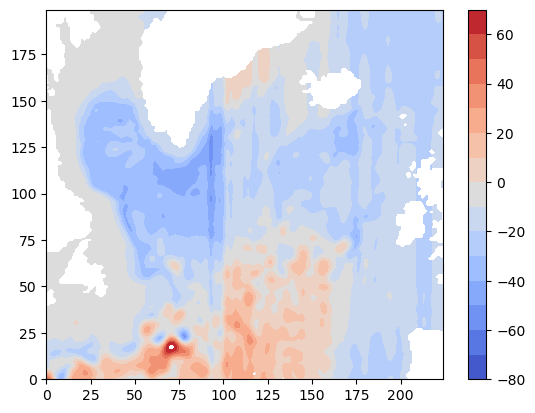

In [7]:
btsf1 = np.cumsum(np.sum(-u_t1 * u_z1, axis = 0) * u_y1, axis = 0)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1[250:450,150:375] / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

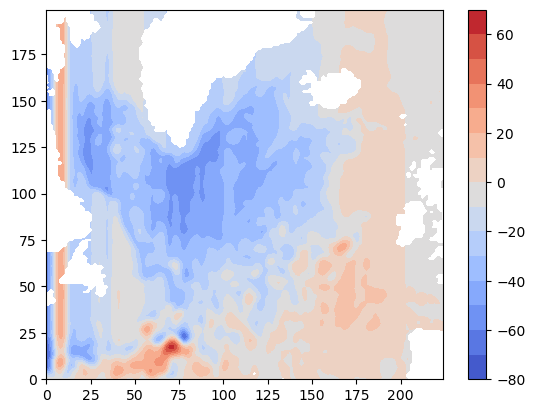

In [8]:
btsf1 = np.cumsum(np.sum(-u_t * u_z, axis = 0) * u_y, axis = 0)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1 / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

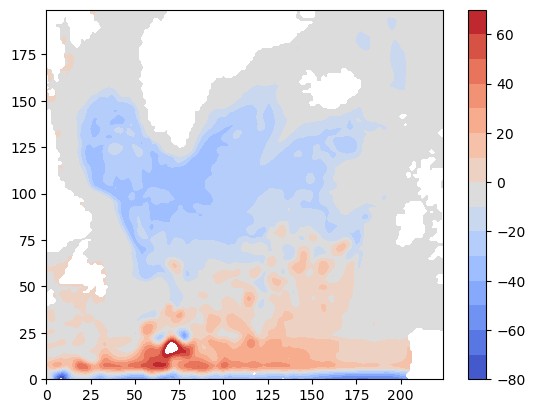

In [9]:
btsf1 = np.cumsum(np.sum(v_t * v_z, axis = 0) * v_x, axis = 1)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1 / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

([<matplotlib.axis.XTick at 0x7f6e813f6110>,
 [Text(25, 0, '-54.6'),
  Text(70, 0, '-43.32'),
  Text(115, 0, '-32.02'),
  Text(160, 0, '-20.7'),
  Text(205, 0, '-9.39')])

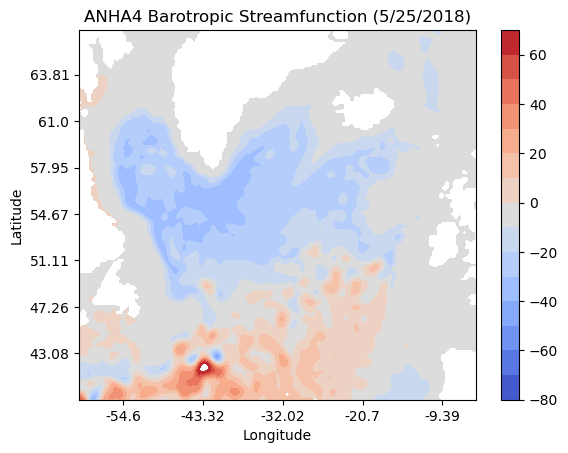

In [50]:
btsf1 = np.cumsum(np.sum(v_t1 * v_z1, axis = 0) * v_x1, axis = 1)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1[250:450,150:375] / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()
plt.title('ANHA4 Barotropic Streamfunction (5/25/2018)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.yticks(np.arange(25,200, 25), np.trunc(v.nav_lat.values[275:450, 150][::25] * 100) / 100)
plt.xticks(np.arange(25,225, 45), np.trunc(v.nav_lon.values[250, 175:375][::45] * 100) / 100)

In [13]:
v12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridV.nc", chunks={'y':800, 'x':544, 'depthv':25})
mask12 = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mask.nc')
hgr = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_hgr.nc')
zgr = xr.open_mfdataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_zgr.nc', chunks={'y':800, 'x':544, 'z':25})

In [52]:
v12

<xarray.Dataset>
Dimensions:       (y: 2400, x: 1632, depthv: 50, time_counter: 1)
Coordinates:
  * depthv        (depthv) float32 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * time_counter  (time_counter) float32 4.406e+07
Dimensions without coordinates: y, x
Data variables:
    nav_lon       (y, x) float32 dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lat       (y, x) float32 dask.array<chunksize=(800, 544), meta=np.ndarray>
    vomecrty      (time_counter, depthv, y, x) float32 dask.array<chunksize=(1, 25, 800, 544), meta=np.ndarray>
    sometauy      (time_counter, y, x) float32 dask.array<chunksize=(1, 800, 544), meta=np.ndarray>
Attributes:
    Conventions:  GDT 1.3
    file_name:    ANHA12-EXH006_y2018m05d25_gridV.nc
    production:   OPA9.0 beta
    TimeStamp:    2018-NOV-21 06:50:10 GMT-0500

In [14]:
v_t12 = v12['vomecrty'][0,:,:,:].rename({'depthv':'z'})
v_z12 = zgr['e3v'][0, :, :,:]
v_x12 = hgr['e1v'][0, :,:]
v_y12 = hgr['e2v'][0,:,:]

([<matplotlib.axis.XTick at 0x7f6e812ce750>,
 [Text(100, 0, '-60.86'),
  Text(200, 0, '-52.51'),
  Text(300, 0, '-44.15'),
  Text(400, 0, '-35.78'),
  Text(500, 0, '-27.41'),
  Text(600, 0, '-19.03')])

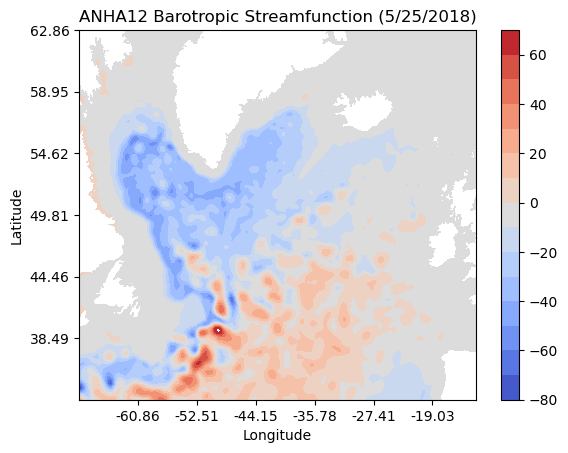

In [51]:
j = np.sum(v_t12 * v_z12, axis = 0)
btsf12 = np.cumsum(j * v_x12, axis = 1)
plt.contourf(np.where(mask12['vmask'][0,0,750:1350,450:1125], btsf12[750:1350,450:1125] / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()
plt.title('ANHA12 Barotropic Streamfunction (5/25/2018)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.yticks([100, 200, 300, 400, 500, 600], np.trunc(v12.nav_lat.values[750:1350, 450][::100] * 100) / 100)
plt.xticks([100, 200, 300, 400, 500, 600], np.trunc(v12.nav_lon.values[750, 450:1000][::100] * 100) / 100)

In [35]:
m = v_t12 * v_x12
p = np.sum(m * v_z12, axis=2)
maskz12 = np.ma.make_mask(p != 0)
p =np.where(maskz12, p, np.nan)
msf12 = np.cumsum(p, axis = 0)

Text(0.5, 1.0, 'ANHA12 Overturning Streamfunction (Sv) 5/25/2018')

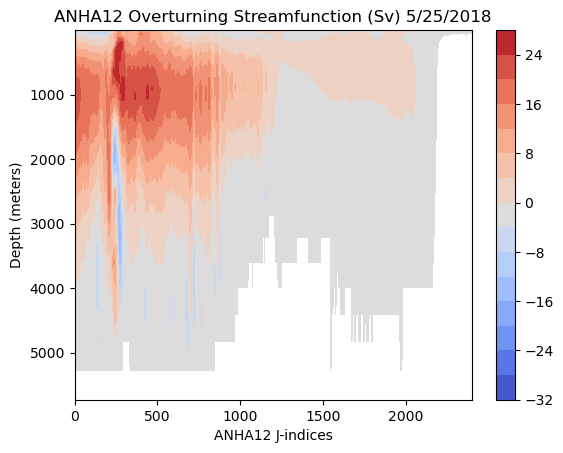

In [38]:
plt.contourf(v12['y'][:], v12['depthv'][:].values, msf12 / 1e6, np.arange(-32, 32, 4), cmap = 'coolwarm')
plt.gca().invert_yaxis()
plt.colorbar()
plt.ylabel('Depth (meters)')
plt.xlabel('ANHA12 J-indices')
plt.title('ANHA12 Overturning Streamfunction (Sv) 5/25/2018')

In [182]:
m = v_t1 * v_x1
p = np.sum(m * v_z1, axis=2)
mask1 = np.ma.make_mask(p != 0)
p =np.where(mask1, p, np.nan)
msf4 = np.cumsum(p, axis = 0)

Text(0.5, 1.0, 'ANHA4 Overturning Streamfunction (Sv) 5/25/2018')

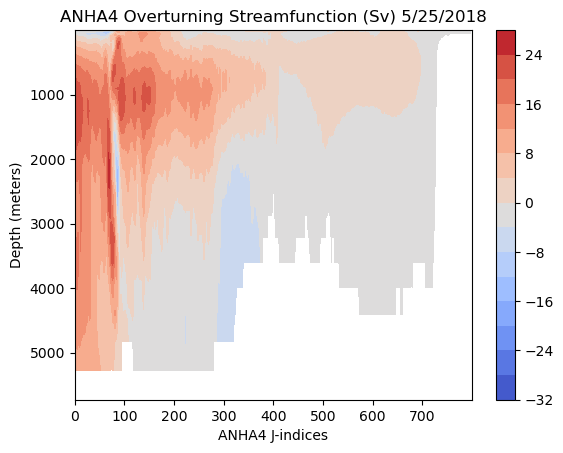

In [198]:
plt.contourf(v['y'][:], v['depth'][:].values, msf4 / 1e6, np.arange(-32, 32, 4), cmap = 'coolwarm')
plt.gca().invert_yaxis()
plt.colorbar()
plt.ylabel('Depth (meters)')
plt.xlabel('ANHA4 J-indices')
plt.title('ANHA4 Overturning Streamfunction (Sv) 5/25/2018')

In [85]:
if __name__ == "__main__":
    inds = [250, 450, 150, 375]
    files, mask = get_files("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25", '/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')
    btsf = barotropic_sf(files, mask, inds)
    #barotropic_plotter(btsf, inds)

(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
